# DPGExplainer Saga Benchmarks — Episode 3: Breast Cancer
A practitioner-friendly walkthrough of Decision Predicate Graphs (DPG) using the Breast Cancer Wisconsin dataset.

This notebook follows the same Iris/Wine pipeline:
- train a baseline Random Forest,
- extract DPG,
- inspect LRC and BC,
- analyze communities and complexity,
- compare DPG-derived boundaries with dataset ranges.


## 1. What is Explainable AI (XAI)
Explainable AI (XAI) helps us understand model behavior beyond raw accuracy.

For this saga, the focus is **global explanation** for tree ensembles:
- not only *which* features matter,
- but *how* threshold predicates combine into model-wide decision logic.


## 2. Why DPG (in one minute)
Random Forest feature importance is useful but limited for structural interpretation.

DPG converts tree paths into a global predicate graph:
- nodes = predicates (`feature <= threshold` or `feature > threshold`),
- edges = transitions observed in decision paths,
- metrics = structural role (routing, bottlenecks, communities).

This is exactly the lens used in Episode 1 (Iris) and Episode 2 (Wine), now applied to a binary medical-classification benchmark.


## 3. Setup (Breast Cancer + Random Forest + DPG)
We train a baseline Random Forest and inspect data geometry with a compact pair plot.


In [1]:
%pip install --force-reinstall --no-deps git+https://github.com/Meta-Group/DPG.git


  Cloning https://github.com/Meta-Group/DPG.git to /private/var/folders/gc/mhnpykzn5n15__6zh66dkf6r0000gn/T/pip-req-build-idsyql5o
  Running command git clone --filter=blob:none --quiet https://github.com/Meta-Group/DPG.git /private/var/folders/gc/mhnpykzn5n15__6zh66dkf6r0000gn/T/pip-req-build-idsyql5o
  Resolved https://github.com/Meta-Group/DPG.git to commit 19da6b1e8eeb09e4da62b31f0b5f406dcdc6858b
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for dpg: filename=dpg-0.1.5-py3-none-any.whl size=41778 sha256=4a5c43c1acc24f3a3a82ecc2f1da6f7bacb2ec2c3b30e8a2dcd81beaf5d90eb5
  Stored in directory: /private/var/folders/gc/mhnpykzn5n15__6zh66dkf6r0000gn/T/pip-ephem-wheel-cache-g1wrr_g2/wheels/dc/1b/f7/79000c8935cb0c07cc77c2dd6e4931f0bc0ff84c354271fdbc
Successfully built dpg
  Attempting uninstall: dpg
    Found existing installation: dpg 0.1.5
    Uninstalling dpg-0.1.5:
      Successfull

In [2]:
import warnings
import sys
import importlib
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Force local package import so notebook uses current repo code, not a previously installed wheel.
cwd = Path.cwd().resolve()
repo_root = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / 'dpg' / '__init__.py').exists() and (candidate / 'pyproject.toml').exists():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError('Could not locate repository root containing dpg package.')

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

for mod in list(sys.modules.keys()):
    if mod == 'dpg' or mod.startswith('dpg.'):
        del sys.modules[mod]

import dpg
import dpg.visualizer as dpg_visualizer
importlib.reload(dpg_visualizer)

print('Using dpg from:', Path(dpg.__file__).resolve())
print('Using visualizer from:', Path(dpg_visualizer.__file__).resolve())


Using dpg from: /Users/barbon/Python/DPG/dpg/__init__.py
Using visualizer from: /Users/barbon/Python/DPG/dpg/visualizer.py


              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



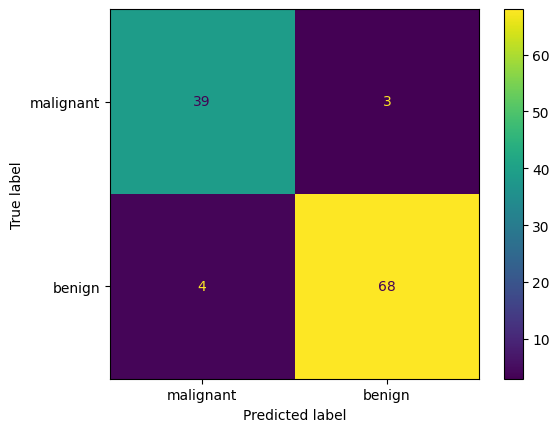

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from dpg import DPGExplainer

IMG_DIR = Path('images')
IMG_DIR.mkdir(parents=True, exist_ok=True)

bc = load_breast_cancer(as_frame=True)
X = bc.data
y = bc.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=10, random_state=27)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=bc.target_names)
disp.plot()
disp.figure_.savefig(IMG_DIR / 'rf_confusion_matrix.png', dpi=200, bbox_inches='tight')
print(classification_report(y_test, y_pred, target_names=bc.target_names))


### 3.1 Pair Plot (Representative Features by Class)
Breast Cancer has 30 features, so we plot a representative subset for readability.


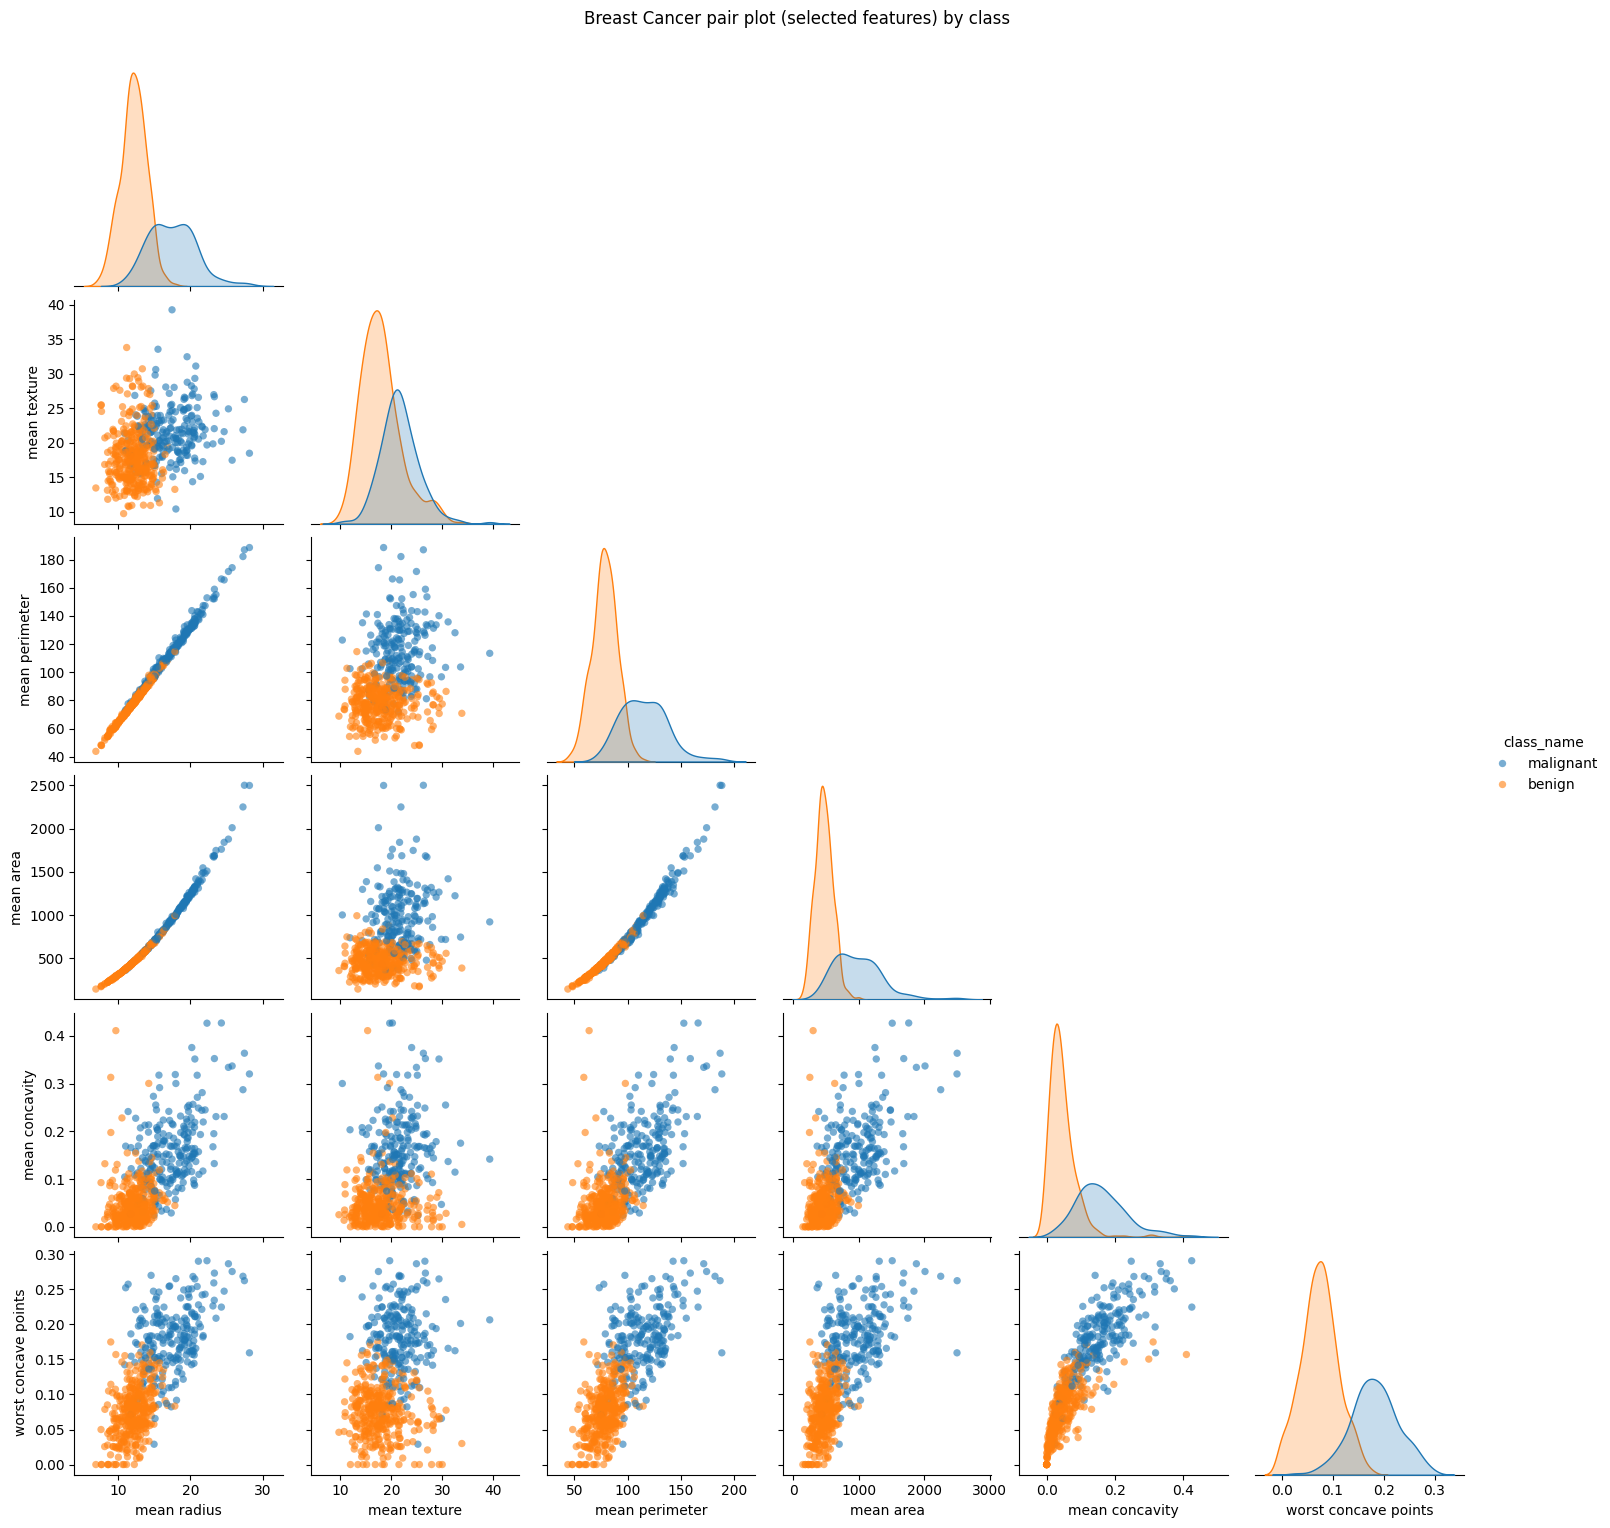

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

pair_features = [
    'mean radius', 'mean texture', 'mean perimeter',
    'mean area', 'mean concavity', 'worst concave points'
]

pair_df = X[pair_features].copy()
pair_df['class_name'] = y.map(lambda i: bc.target_names[i])

g = sns.pairplot(
    pair_df,
    hue='class_name',
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6, 's': 28, 'edgecolor': 'none'},
)
g.fig.suptitle('Breast Cancer pair plot (selected features) by class', y=1.02)
g.fig.savefig(IMG_DIR / 'pairplot.png', dpi=200, bbox_inches='tight')
plt.show()


## 4. Extracting DPG from RF
We extract a global explanation from RF and keep community analysis enabled.


In [5]:
explainer = DPGExplainer(
    model=model,
    feature_names=X.columns,
    target_names=bc.target_names.tolist(),
    config_file="config.yaml",  # optional if present
)

explanation = explainer.explain_global(
    X.values,
    communities=True,
    community_threshold=0.2,
)


Config file not found at 'config.yaml'. Using built-in defaults.
DPG initialized with perc_var=1e-09, decimal_threshold=6, n_jobs=-1

Starting DPG extraction *****************************************
Model Class: RandomForestClassifier
Model Class Module: sklearn.ensemble._forest
Model Estimators:  10
Model Params:  {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 10, 'n_jobs': None, 'oob_score': False, 'random_state': 27, 'verbose': 0, 'warm_start': False}
*****************************************************************


100%|██████████| 569/569 [00:01<00:00, 300.20it/s]


Total of paths: 5690
Building DPG...


Processing cases: 100%|██████████| 5690/5690 [00:00<00:00, 30077.80it/s]


Extracting graph...


/Users/barbon/Python/DPG/metrics/graph.py:337: RuntimeWarning: divide by zero encountered in matmul
  B = N @ R
/Users/barbon/Python/DPG/metrics/graph.py:337: RuntimeWarning: overflow encountered in matmul
  B = N @ R
/Users/barbon/Python/DPG/metrics/graph.py:337: RuntimeWarning: invalid value encountered in matmul
  B = N @ R


## 5. Read the DPG Metrics
`node_metrics` and `edge_metrics` are the core tables for downstream interpretation.


In [6]:
explanation.node_metrics.head()


,Node,Degree,In degree nodes,Out degree nodes,Betweenness centrality,Local reaching centrality,Label
0,857545575890718313637784943619545629465616819813,3,1,2,0.000056,0.014554,worst radius <= 15.505
1,189019628259920352920923569857707905426154671507,2,1,1,0.000016,0.000056,mean compactness > 0.2536
2,325511774797466532711184906042286573696262505601,93,93,0,0.000000,0.000000,Class malignant
3,1305485673746848381153094589665065558072067884195,6,2,4,0.000668,0.082672,worst concavity <= 0.37875
4,1354645370136574270109244119633354433863942464322,2,1,1,0.000008,0.000056,concave points error > 0.018075


**Local Reaching Centrality (LRC)**
- High LRC nodes can reach many downstream predicates.
- They typically capture early routing logic in the global decision flow.


## 6. Compare Top LRC Predicates vs Random Forest Importance
This keeps the same complementary perspective used in Iris and Wine.


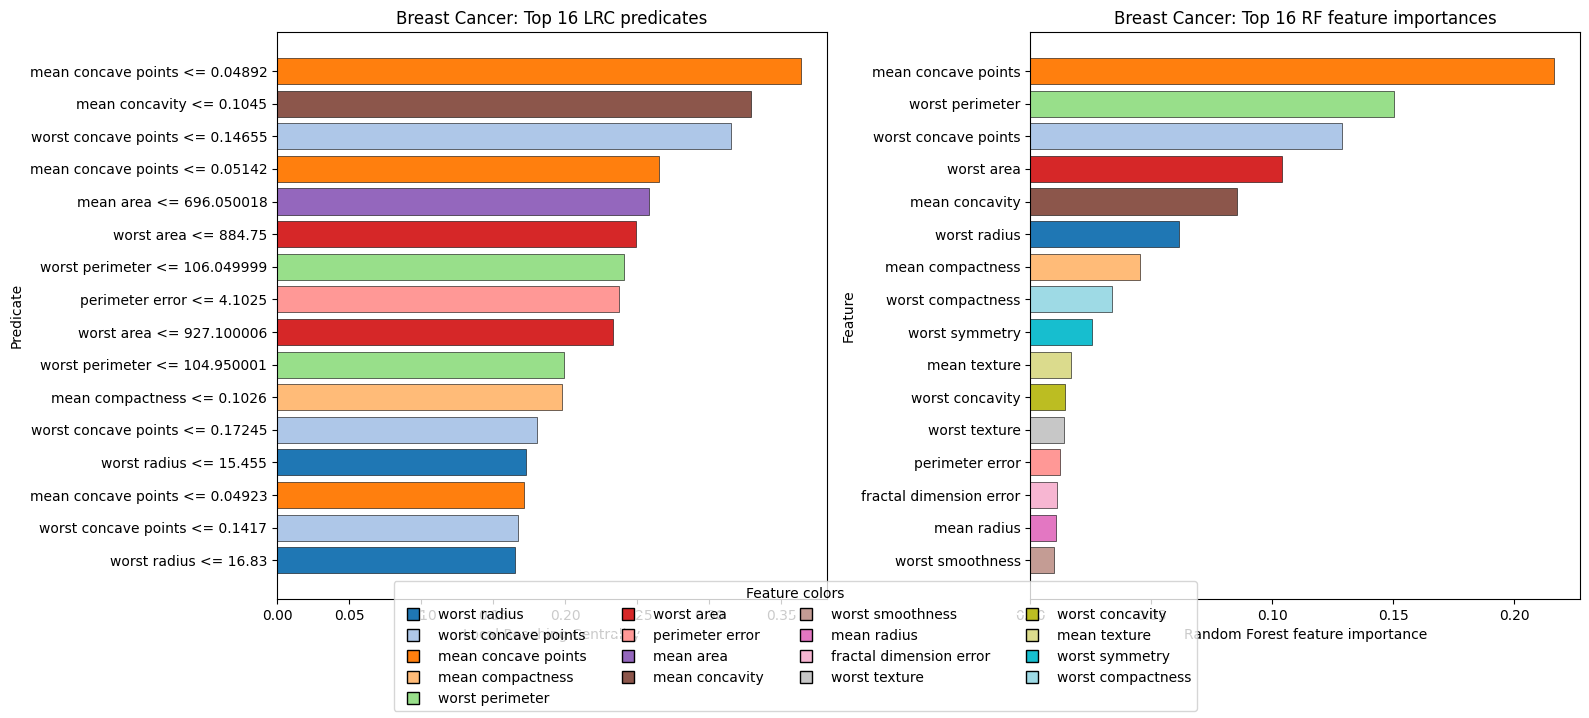

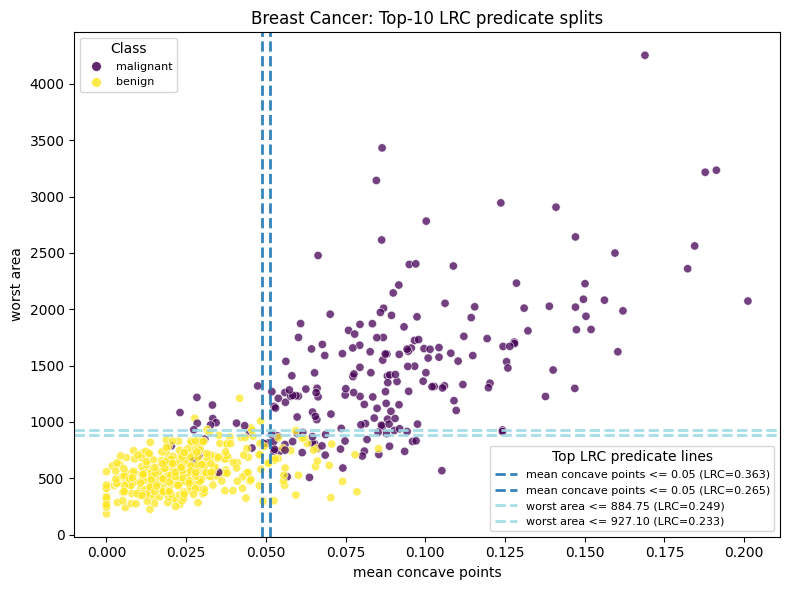

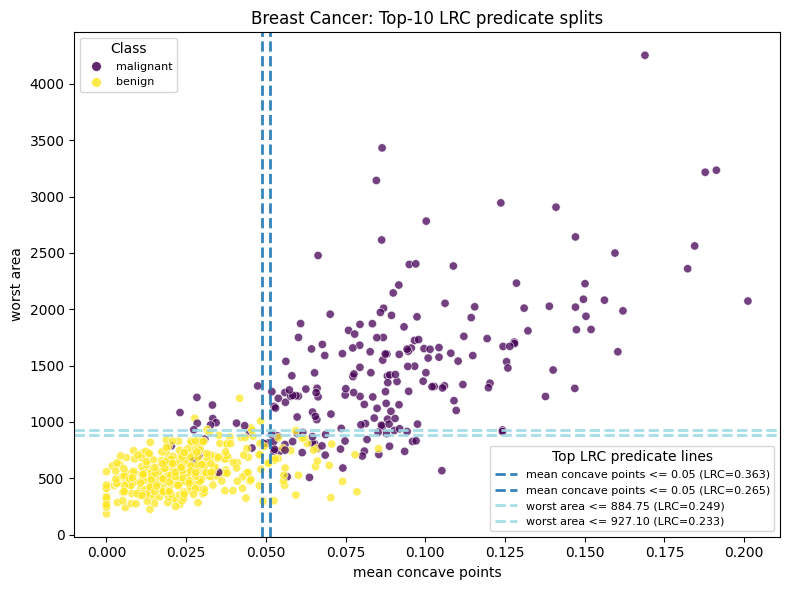

In [7]:
import dpg.visualizer as dpg_visualizer

plot_lrc_vs_rf_importance = dpg_visualizer.plot_lrc_vs_rf_importance
plot_top_lrc_predicate_splits = dpg_visualizer.plot_top_lrc_predicate_splits

plot_lrc_vs_rf_importance(
    explanation=explanation,
    model=model,
    X_df=X,
    top_k=16,
    dataset_name='Breast Cancer',
    save_path=str(IMG_DIR / 'lrc_vs_rf_importance.png'),
    show=True,
)

plot_top_lrc_predicate_splits(
    explanation=explanation,
    X_df=X,
    y=y,
    top_predicates=10,
    top_features=2,
    dataset_name='Breast Cancer',
    class_names=bc.target_names,
    save_path=str(IMG_DIR / 'top_lrc_predicate_splits.png'),
    show=True,
)


### Optional: inspect top-10 LRC and RF tables


In [8]:
top_lrc = (
    explanation.node_metrics
    .loc[
        explanation.node_metrics['Label'].astype(str).str.contains('<=', regex=False)
        | explanation.node_metrics['Label'].astype(str).str.contains('>', regex=False),
        ['Label', 'Local reaching centrality'],
    ]
    .sort_values('Local reaching centrality', ascending=False)
    .head(10)
)

top_rf = (
    pd.DataFrame({
        'feature': list(getattr(model, 'feature_names_in_', X.columns)),
        'rf_importance': model.feature_importances_.astype(float),
    })
    .sort_values('rf_importance', ascending=False)
    .head(10)
)

display(top_lrc)
display(top_rf)


,Label,Local reaching centrality
280,mean concave points <= 0.04892,0.363338
271,mean concavity <= 0.1045,0.328992
310,worst concave points <= 0.14655,0.314939
289,mean concave points <= 0.05142,0.265294
185,mean area <= 696.050018,0.258134
328,worst area <= 884.75,0.249449
220,worst perimeter <= 106.049999,0.240473
285,perimeter error <= 4.1025,0.237174
11,worst area <= 927.100006,0.233047
264,worst perimeter <= 104.950001,0.199184


,feature,rf_importance
7,mean concave points,0.216308
22,worst perimeter,0.150218
27,worst concave points,0.128881
23,worst area,0.104094
6,mean concavity,0.085259
20,worst radius,0.061277
5,mean compactness,0.045290
25,worst compactness,0.033751
28,worst symmetry,0.025696
1,mean texture,0.016796


Interpretation guide:
- High **LRC** means a predicate has strong structural influence.
- High **RF importance** means a feature contributes strongly to impurity reduction.
- Overlap between both signals indicates robust decision relevance.


## 7. Show BC Bottleneck Cloud in PCA Space
Betweenness centrality (BC) highlights bridge predicates between decision regions.


/Users/barbon/Python/DPG/.venv/lib/python3.11/site-packages/sklearn/decomposition/_base.py:149: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/barbon/Python/DPG/.venv/lib/python3.11/site-packages/sklearn/decomposition/_base.py:149: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/barbon/Python/DPG/.venv/lib/python3.11/site-packages/sklearn/decomposition/_base.py:149: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


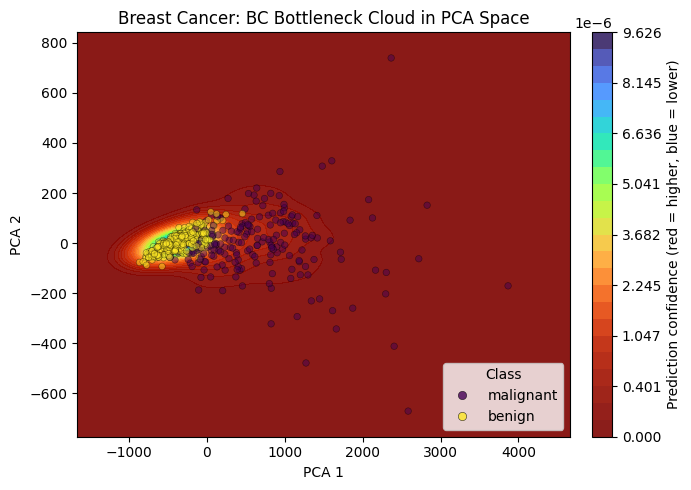

In [9]:
import seaborn as sns
from sklearn.decomposition import PCA
import re
from matplotlib.lines import Line2D


def bc_weights_from_explanation(explanation, X_df, top_k=10):
    nm = explanation.node_metrics.copy()
    nm = nm[nm["Label"].str.contains("<=", regex=False, na=False) | nm["Label"].str.contains(">", regex=False, na=False)].copy()
    top_bc = nm.sort_values("Betweenness centrality", ascending=False).head(top_k)

    weights = np.zeros(len(X_df), dtype=float)

    for _, row in top_bc.iterrows():
        parsed = re.search(r"(.+?)\s*(<=|>)\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", str(row["Label"]))
        if not parsed:
            continue
        feature = parsed.group(1).strip()
        op = parsed.group(2)
        threshold = float(parsed.group(3))
        if feature not in X_df.columns:
            continue

        vals = X_df[feature].values
        vals = np.where(np.isfinite(vals), vals, np.nan)
        if op == '<=':
            weights += (vals <= threshold)
        else:
            weights += (vals > threshold)

    if weights.max() > 0:
        weights = weights / weights.max()
    return weights


def pca_kde_plot(X_df, y, weights, title, save_path=None, class_names=None):
    X_clean = X_df.replace([np.inf, -np.inf], np.nan)
    valid_mask = ~X_clean.isna().any(axis=1)
    X_valid = X_clean[valid_mask]
    y_valid = y[valid_mask]
    w_valid = weights[valid_mask]

    pca = PCA(n_components=2, random_state=27)
    X_pca = pca.fit_transform(X_valid)

    fig, ax = plt.subplots(1, 1, figsize=(7, 5), facecolor='white')
    ax.set_facecolor('#f6d6d6')

    try:
        kde = sns.kdeplot(
            x=X_pca[:, 0],
            y=X_pca[:, 1],
            weights=w_valid,
            fill=True,
            levels=25,
            cmap='turbo_r',
            alpha=0.9,
            thresh=0.0,
            bw_adjust=1.15,
            ax=ax,
        )
        if hasattr(kde, 'collections') and kde.collections:
            cbar = fig.colorbar(kde.collections[0], ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label('Prediction confidence (red = higher, blue = lower)')
    except Exception:
        hb = ax.hexbin(
            X_pca[:, 0],
            X_pca[:, 1],
            C=w_valid,
            reduce_C_function=np.mean,
            gridsize=35,
            cmap='turbo_r',
            mincnt=1,
            alpha=0.9,
        )
        cbar = fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Prediction confidence (red = higher, blue = lower)')

    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=y_valid,
        cmap='viridis',
        s=22,
        alpha=0.5,
        edgecolor='k',
        linewidth=0.4,
    )

    unique_classes = sorted(pd.Series(y_valid).dropna().unique())
    legend_handles = []
    for cls in unique_classes:
        cls_idx = int(cls)
        if class_names is None:
            class_label = f'class_{cls_idx}'
        elif isinstance(class_names, dict):
            class_label = class_names.get(cls_idx, f'class_{cls_idx}')
        else:
            class_label = class_names[cls_idx] if cls_idx < len(class_names) else f'class_{cls_idx}'

        legend_handles.append(
            Line2D(
                [0], [0],
                marker='o',
                color='w',
                markerfacecolor=scatter.cmap(scatter.norm(cls_idx)),
                markeredgecolor='k',
                markeredgewidth=0.4,
                markersize=6,
                linestyle='None',
                alpha=0.8,
                label=class_label,
            )
        )

    if legend_handles:
        ax.legend(handles=legend_handles, title='Class', loc='lower right', frameon=True)

    ax.set_title(title)
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


weights = bc_weights_from_explanation(explanation, X, top_k=10)
pca_kde_plot(
    X, y, weights, 'Breast Cancer: BC Bottleneck Cloud in PCA Space',
    save_path=IMG_DIR / 'bc_bottleneck_pca_cloud.png',
    class_names=bc.target_names,
)


## 8. Communities (Decision Themes + Class Complexity)
Community analysis summarizes how predicates organize by class.


In [10]:
import seaborn as sns
from dpg.visualizer import class_feature_predicate_counts


def plot_class_feature_complexity(heat_df, dataset_name='Breast Cancer', top_n_features=15, save_prefix=None):
    if heat_df.empty:
        print(f'{dataset_name}: no class-feature predicate counts available.')
        return

    h = heat_df.copy()
    if h.shape[1] > top_n_features:
        h = h.iloc[:, :top_n_features]

    h_norm = h.div(h.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

    fig, axes = plt.subplots(1, 2, figsize=(18, max(5, 0.6 * len(h.index) + 2)))

    sns.heatmap(
        h,
        annot=True,
        fmt='d',
        cmap='YlOrRd',
        linewidths=0.4,
        linecolor='white',
        ax=axes[0],
    )
    axes[0].set_title(f'{dataset_name}: Class vs Feature predicate counts')
    axes[0].set_xlabel('Feature')
    axes[0].set_ylabel('Class')

    sns.heatmap(
        h_norm,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        linewidths=0.4,
        linecolor='white',
        ax=axes[1],
    )
    axes[1].set_title(f'{dataset_name}: Row-normalized feature share by class')
    axes[1].set_xlabel('Feature')
    axes[1].set_ylabel('Class')

    plt.tight_layout()
    if save_prefix is not None:
        fig.savefig(save_prefix + '_heatmap.png', dpi=200, bbox_inches='tight')
    plt.show()

    complexity = pd.DataFrame({
        'total_predicates': h.sum(axis=1),
        'unique_features': (h > 0).sum(axis=1),
    }).sort_values('total_predicates', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.barplot(
        x=complexity.index,
        y=complexity['total_predicates'],
        palette='Reds_r',
        ax=axes[0],
    )
    axes[0].set_title(f'{dataset_name}: Predicate volume by class')
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Total predicate count')

    sns.barplot(
        x=complexity.index,
        y=complexity['unique_features'],
        palette='Blues_r',
        ax=axes[1],
    )
    axes[1].set_title(f'{dataset_name}: Feature coverage by class')
    axes[1].set_xlabel('Class')
    axes[1].set_ylabel('Unique features in predicates')

    plt.tight_layout()
    if save_prefix is not None:
        fig.savefig(save_prefix + '_bars.png', dpi=200, bbox_inches='tight')
    plt.show()


In [11]:
explanation.communities.keys()
explanation.communities.get("Clusters", explanation.communities.get("Communities", []))


{'Class benign': ['worst radius <= 15.505',
  'worst concavity <= 0.37875',
  'mean concavity <= 0.072265',
  'worst concave points <= 0.17245',
  'worst concave points <= 0.10855',
  'worst area <= 927.100006',
  'mean area <= 567.649994',
  'worst concavity > 1.1785',
  'Class benign',
  'worst area <= 677.100006',
  'worst concave points <= 0.10565',
  'mean texture <= 16.895',
  'concavity error > 0.13565',
  'mean smoothness > 0.090425',
  'mean compactness <= 0.2536',
  'concavity error > 0.030115',
  'area error <= 58.355',
  'worst fractal dimension <= 0.06893',
  'area error > 46.315001',
  'worst compactness > 0.08476',
  'symmetry error <= 0.009835',
  'worst symmetry <= 0.2294',
  'mean perimeter > 94.899998',
  'worst symmetry > 0.31155',
  'mean texture > 12.18',
  'smoothness error > 0.009333',
  'smoothness error <= 0.003679',
  'mean area <= 773.600006',
  'worst radius > 16.95',
  'mean compactness <= 0.1289',
  'mean area <= 708.800018',
  'texture error > 1.458',
  

Plotting DPG...


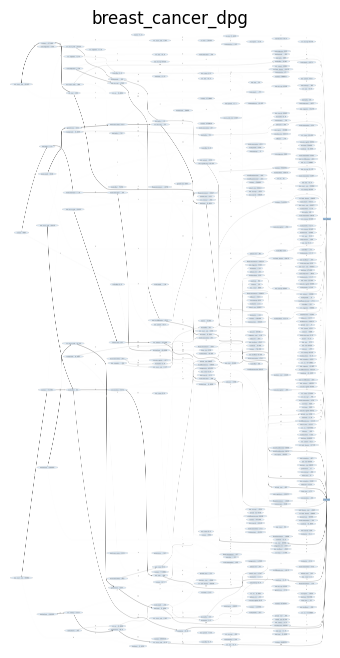

In [12]:
run_name = "breast_cancer_dpg"
explainer.plot(run_name, explanation, save_dir=str(IMG_DIR), class_flag=True, export_pdf=True, dpi=600)


Plotting DPG (communities)...


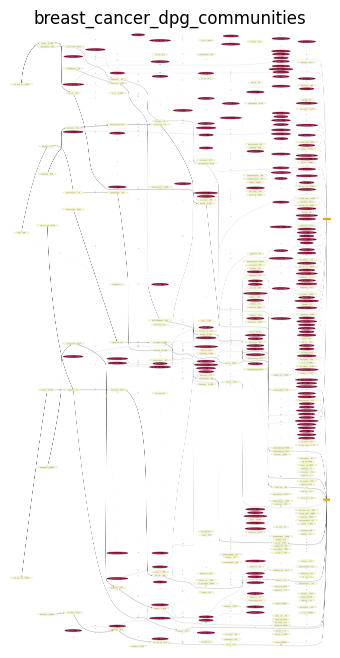

In [13]:
run_name = "breast_cancer_dpg"
explainer.plot_communities(run_name, explanation, save_dir=str(IMG_DIR), class_flag=True, export_pdf=True, dpi=600)


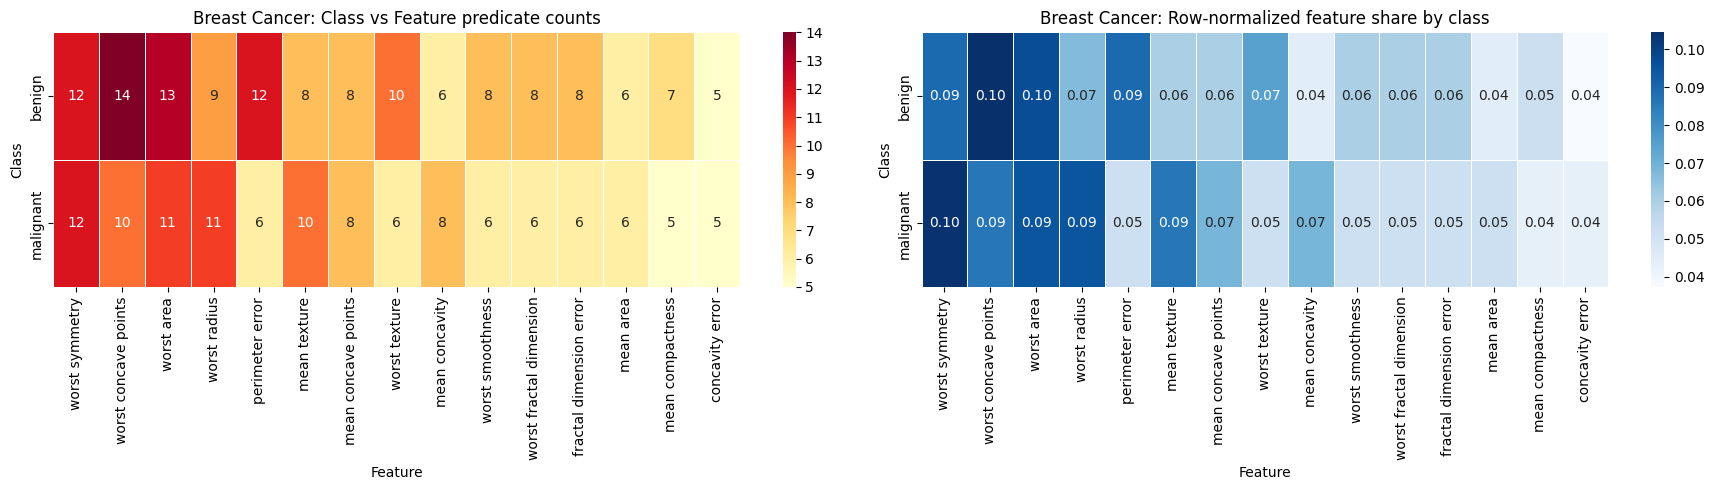

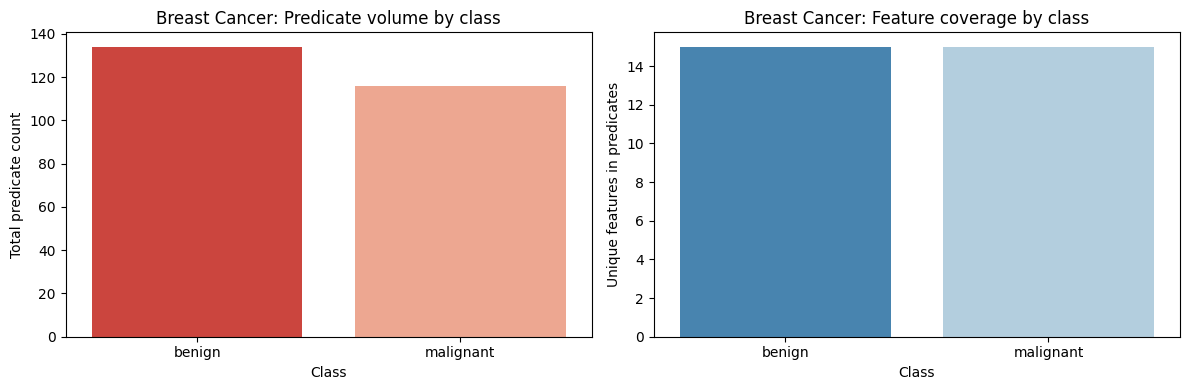

In [14]:
heat = class_feature_predicate_counts(explanation)
plot_class_feature_complexity(
    heat, dataset_name='Breast Cancer', top_n_features=15,
    save_prefix=str(IMG_DIR / 'communities_class_feature_complexity')
)


In [15]:
from dpg.visualizer import (
    classwise_feature_bounds_from_communities,
    class_feature_predicate_positions,
    class_lookup_from_target_names,
    plot_dpg_class_bounds_vs_dataset_feature_ranges,
)


In [16]:
class_bounds = classwise_feature_bounds_from_communities(explanation)
print(class_bounds)
class_lookup = class_lookup_from_target_names(bc.target_names if 'bc' in globals() else None)
predicate_positions = class_feature_predicate_positions(explanation)
print(predicate_positions.head(10))


   class_name  community_id                  feature  lower_bound  \
0      benign             0           symmetry error     0.009835   
1      benign             0               area error    42.320002   
2      benign             0          worst concavity     0.224200   
3      benign             0      mean concave points     0.030440   
4      benign             0                mean area   567.649994   
5      benign             0           mean concavity     0.054505   
6      benign             0           worst symmetry     0.156550   
7      benign             0               worst area   566.549988   
8      benign             0     worst concave points     0.092290   
9      benign             0              mean radius    13.725000   
10     benign             0            texture error     1.378000   
11     benign             0        worst compactness     0.084760   
12     benign             0            worst texture    28.335000   
13     benign             0       

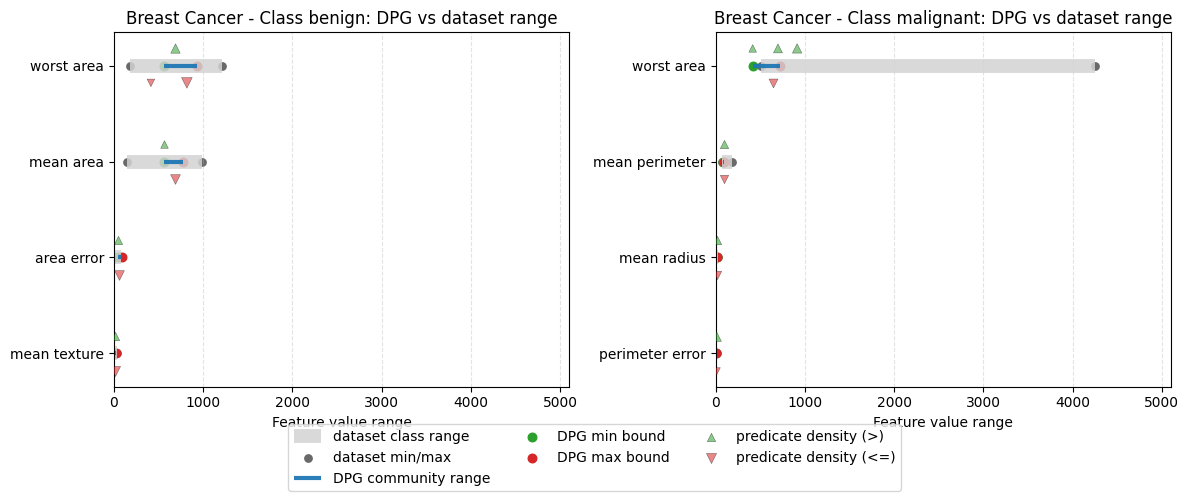

In [17]:
_ = plot_dpg_class_bounds_vs_dataset_feature_ranges(
    explanation=explanation,
    X_df=X,
    y=y,
    dataset_name='Breast Cancer',
    top_features=4,
    feature_cols_per_row=4,
    class_lookup=class_lookup,
    predicate_positions=predicate_positions,
    class_bounds=class_bounds,
    save_path=str(IMG_DIR / 'dpg_vs_dataset_feature_ranges.png'),
)



## 9. What to Say in the Story
Use this narrative to highlight DPG value in practice:
- **LRC as global logic driver:** identifies structurally dominant thresholds.
- **BC as routing bottleneck signal:** identifies bridge predicates between dense decision regions.
- **Communities as rule themes:** converts many tree paths into interpretable decision modules.
- **Class complexity:** compares rule volume and feature coverage by class.
- **Boundary validation:** checks DPG-induced class ranges against empirical dataset ranges.

Episode-to-episode link:
- Iris: cleaner geometry, fewer interacting rules.
- Wine: moderate overlap, richer threshold composition.
- Breast Cancer: higher-dimensional binary separation with dense threshold interactions and stronger boundary asymmetry.


## Next Episode
Move to another benchmark and keep the same benchmark protocol for cross-dataset comparability.
